In [1]:
# Cellule 1 — Imports et setup
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from afs_model import AFSParams, optimal_impact, pnl_optimal, pnl_misspecified, profit_ratio_concavity

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup OK")

Setup OK


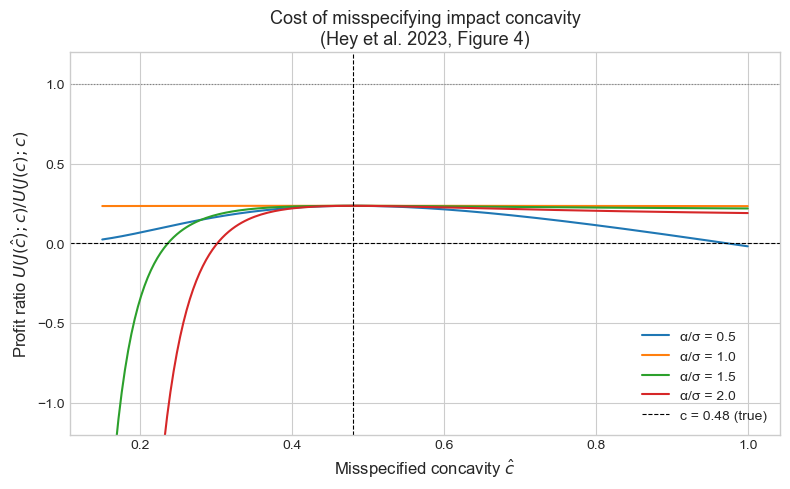

In [2]:
# Cellule 2 — Profit ratio vs c_hat (Figure 4 Hey et al.)

params_true = AFSParams(c=0.48, tau=0.2)
T = 1.0
c_hat_grid = np.linspace(0.15, 1.0, 200)

# Différents niveaux de Sharpe alpha/sigma
sharpe_levels = [0.5, 1.0, 1.5, 2.0]

fig, ax = plt.subplots(figsize=(8, 5))

for sharpe in sharpe_levels:
    alpha = sharpe  # sigma=1 donc alpha/sigma = alpha
    ratios = profit_ratio_concavity(alpha, params_true, c_hat_grid, T)
    ax.plot(c_hat_grid, ratios, label=f'α/σ = {sharpe}')

# Ligne de référence
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(x=params_true.c, color='black', linestyle='--', 
           linewidth=0.8, label=f'c = {params_true.c} (true)')

ax.set_xlabel('Misspecified concavity $\\hat{c}$', fontsize=12)
ax.set_ylabel('Profit ratio $U(J(\\hat{c}); c) / U(J(c); c)$', fontsize=12)
ax.set_title('Cost of misspecifying impact concavity\n(Hey et al. 2023, Figure 4)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig('../figures/fig4_profit_ratio_concavity.png', dpi=150)
plt.show()

In [5]:
import importlib
import afs_model
importlib.reload(afs_model)
from afs_model import AFSParams, pnl_optimal, profit_ratio_decay

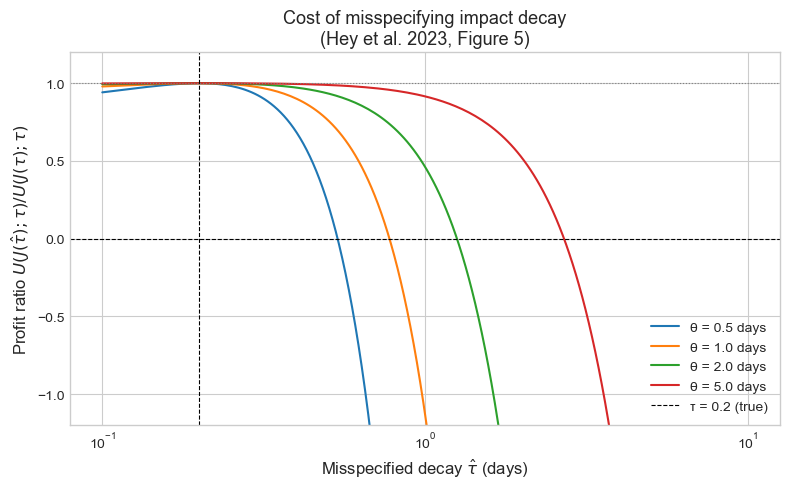

In [6]:
# Cellule 3 — Profit ratio vs tau_hat (Figure 5 Hey et al.)
import sys
sys.path.append('../src')
from afs_model import AFSParams, pnl_optimal, profit_ratio_decay

params_true = AFSParams(c=0.48, tau=0.2)
T = 1.0
tau_hat_grid = np.logspace(-1, 1, 200)  # de 0.1 à 10 jours en log scale

# Différents niveaux de decay alpha theta
theta_levels = [0.5, 1.0, 2.0, 5.0]

fig, ax = plt.subplots(figsize=(8, 5))

for theta in theta_levels:
    ratios = profit_ratio_decay(params_true, tau_hat_grid, theta, T)
    ax.plot(tau_hat_grid, ratios, label=f'θ = {theta} days')

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(x=params_true.tau, color='black', linestyle='--',
           linewidth=0.8, label=f'τ = {params_true.tau} (true)')

ax.set_xscale('log')
ax.set_xlabel('Misspecified decay $\\hat{τ}$ (days)', fontsize=12)
ax.set_ylabel('Profit ratio $U(J(\\hat{τ}); τ) / U(J(τ); τ)$', fontsize=12)
ax.set_title('Cost of misspecifying impact decay\n(Hey et al. 2023, Figure 5)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig('../figures/fig5_profit_ratio_decay.png', dpi=150)
plt.show()